In [ ]:
#  HR Analytics Project – Employee Attrition & Income Prediction

This project uses the **IBM HR Employee Attrition dataset** to analyse employee data.  
Main objectives:
- Understand the factors affecting employee attrition.
- Predict employee monthly income using regression models.

We will perform:
1. Data Cleaning  
2. Exploratory Data Analysis (EDA)  
3. Model Training & Evaluation  
4. Insights & Future Improvements

# Dataset Overview

- **Dataset Name**: WA_Fn-UseC_-HR-Employee-Attrition.csv  
- **Rows & Columns**: Employee details including age, department, role, education, experience, income, and attrition.  
- **Target Variable**:
  - `Attrition` (Yes/No) → Classification Problem
  - `MonthlyIncome` → Regression Problem

We will focus mainly on **predicting Monthly Income** using regression.

# Data Cleaning

Steps performed:
- Checked for missing values → None found.  
- Checked for duplicate rows → Removed duplicates if any.  
- Verified data types (categorical vs numerical).  
- Encoded categorical features using Label Encoding/One-Hot Encoding.  
- Standardised numerical features using StandardScaler.

# Exploratory Data Analysis (EDA)

We visualised:
- Attrition distribution (Yes/No).  
- Monthly Income distribution.  
- Correlation heatmap between numerical features.  
- Boxplots and histograms for key attributes (Age, Job Role, Department, etc.).  

   EDA helps us identify which features strongly affect employee income and attrition.


# Model Training

We trained a **Linear Regression model** on the dataset:
- Features (X): Employee details after encoding & scaling.  
- Target (y): Monthly Income.  

Steps:
1. Split dataset into training & testing sets.  
2. Train the Linear Regression model.  
3. Predict Monthly Income for test employees.


# Model Evaluation

Evaluation metrics used:
- Mean Absolute Error (MAE)  
- Mean Squared Error (MSE)  
- Root Mean Squared Error (RMSE)  
- R² Score  

Visualisations:
- Actual vs Predicted plot  
- Residual plot  
- Feature importance (coefficients)


# Conclusion & Future Work

### Conclusion:
- Built a Linear Regression model to predict employee monthly income.  
- Achieved reasonable accuracy with R² score and low error values.  

### Future Improvements:
1. Try **Classification models** (Logistic Regression, Random Forest, XGBoost) for Attrition Prediction.  
2. Perform **Feature Engineering** (interaction features, polynomial features).  
3. Use **Regularisation** (Ridge/Lasso) to reduce overfitting.  
4. Compare different models and choose the best performer.  
5. Deploy model as a web app using **Flask/Streamlit**.


In [65]:
# Step 1: Imports & basic setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
# Load dataset
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [6]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [10]:
df.head(3)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0


In [11]:
df.tail(3)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,...,1,80,0,6,3,4,4,3,1,2


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [12]:
df.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

In [13]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [14]:
df.duplicated().sum()

0

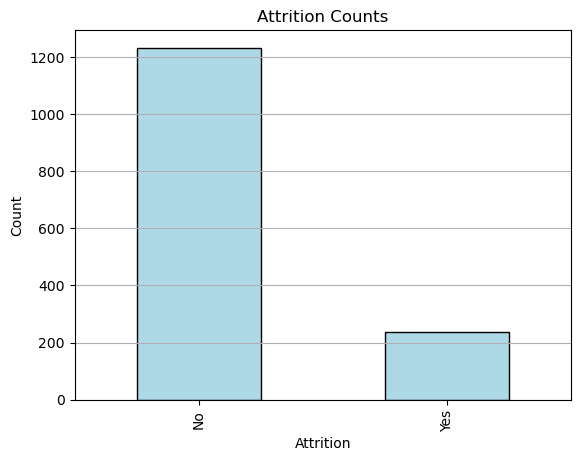

In [15]:
df['Attrition'].value_counts().plot(kind='bar', color='lightblue', edgecolor='black')
plt.title("Attrition Counts")
plt.xlabel("Attrition")
plt.ylabel("Count")
plt.grid(axis='y')
plt.show()


In [16]:
# Department wise count
df['Department'].value_counts()


Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

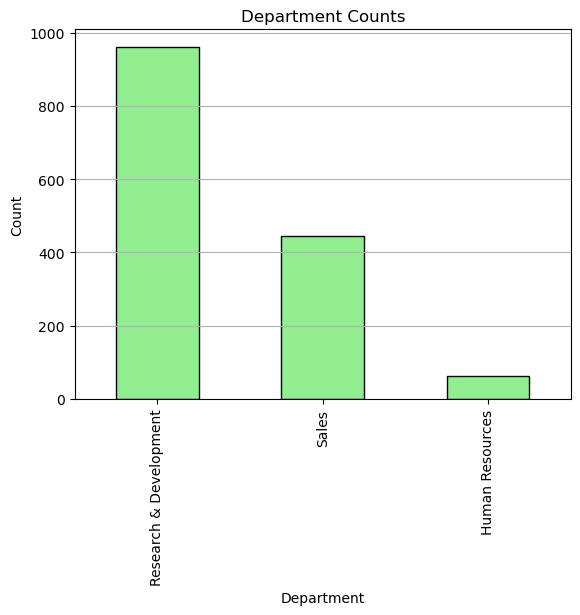

In [17]:
# Bar chart for Department
df['Department'].value_counts().plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title("Department Counts")
plt.xlabel("Department")
plt.ylabel("Count")
plt.grid(axis='y')
plt.show()


In [18]:
# JobRole wise count
df['JobRole'].value_counts()


JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64

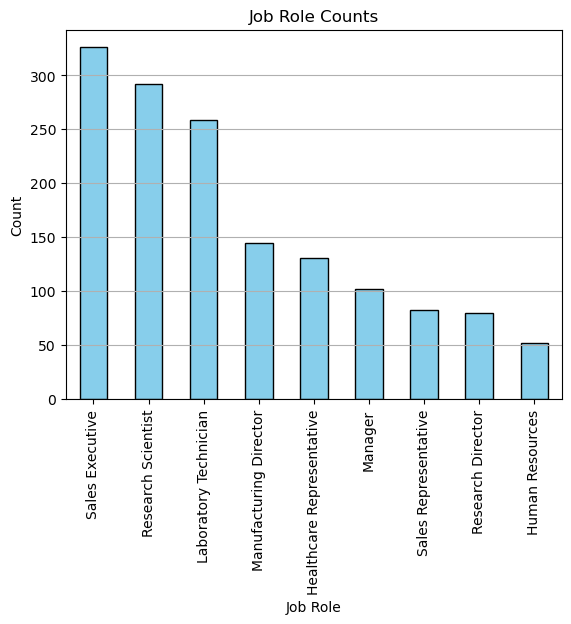

In [19]:
# Bar chart for JobRole
df['JobRole'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Job Role Counts")
plt.xlabel("Job Role")
plt.ylabel("Count")
plt.grid(axis='y')
plt.show()


In [20]:
# EducationField wise count
df['EducationField'].value_counts()


EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

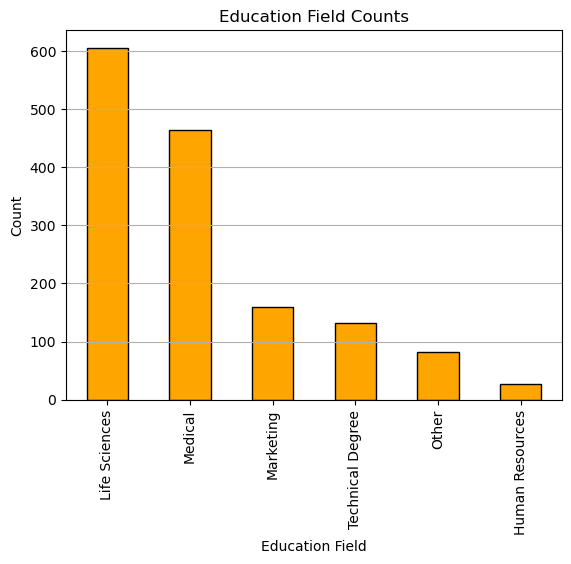

In [21]:
# Bar chart for EducationField
df['EducationField'].value_counts().plot(kind='bar', color='orange', edgecolor='black')
plt.title("Education Field Counts")
plt.xlabel("Education Field")
plt.ylabel("Count")
plt.grid(axis='y')
plt.show()


In [22]:
# Gender wise count (Male vs Female employees)
df['Gender'].value_counts()


Gender
Male      882
Female    588
Name: count, dtype: int64

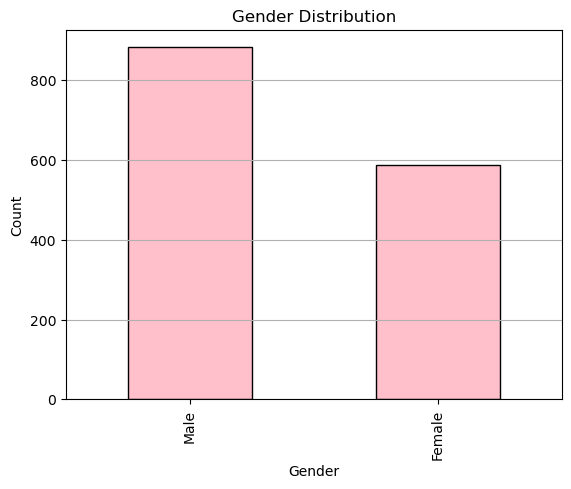

In [23]:
# Bar chart for Gender
df['Gender'].value_counts().plot(kind='bar', color='pink', edgecolor='black')
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.grid(axis='y')
plt.show()


In [24]:
# MaritalStatus wise count (Single, Married, Divorced employees)
df['MaritalStatus'].value_counts()


MaritalStatus
Married     673
Single      470
Divorced    327
Name: count, dtype: int64

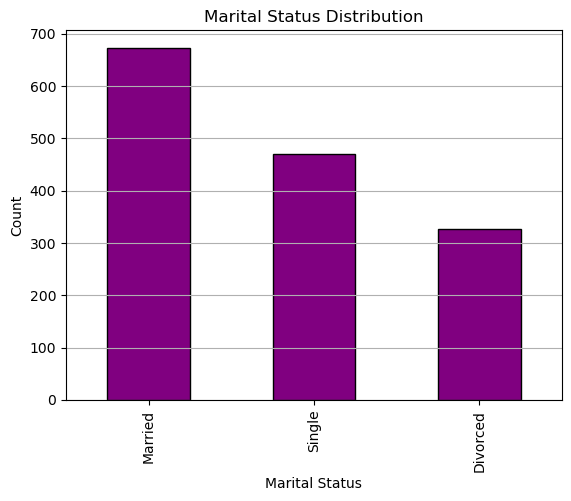

In [25]:
# Bar chart for MaritalStatus
df['MaritalStatus'].value_counts().plot(kind='bar', color='purple', edgecolor='black')
plt.title("Marital Status Distribution")
plt.xlabel("Marital Status")
plt.ylabel("Count")
plt.grid(axis='y')
plt.show()


In [26]:
# BusinessTravel wise count (Travel_Rarely, Travel_Frequently, Non-Travel)
df['BusinessTravel'].value_counts()


BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

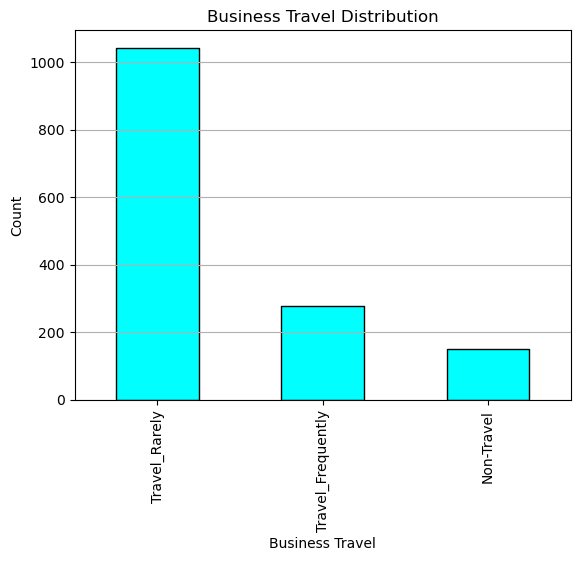

In [27]:
# Bar chart for BusinessTravel
df['BusinessTravel'].value_counts().plot(kind='bar', color='cyan', edgecolor='black')
plt.title("Business Travel Distribution")
plt.xlabel("Business Travel")
plt.ylabel("Count")
plt.grid(axis='y')
plt.show()


In [28]:
# OverTime wise count (Yes vs No)
df['OverTime'].value_counts()


OverTime
No     1054
Yes     416
Name: count, dtype: int64

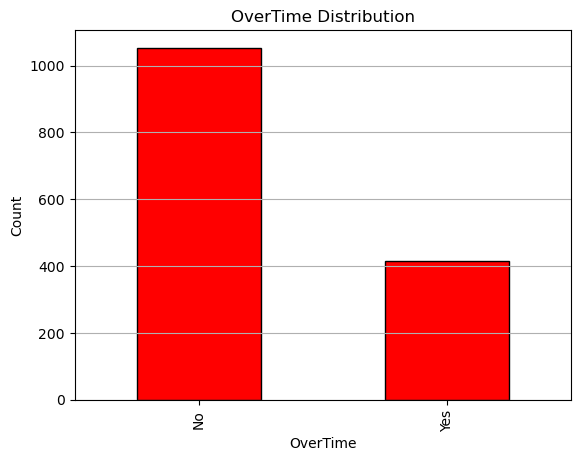

In [29]:
# Bar chart for OverTime
df['OverTime'].value_counts().plot(kind='bar', color='red', edgecolor='black')
plt.title("OverTime Distribution")
plt.xlabel("OverTime")
plt.ylabel("Count")
plt.grid(axis='y')
plt.show()


In [32]:
# Only choose numercial columns 
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols


['Age',
 'DailyRate',
 'DistanceFromHome',
 'Education',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobSatisfaction',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [33]:
# Summary statistics (mean, std, min, max, etc.)
df[numeric_cols].describe()


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


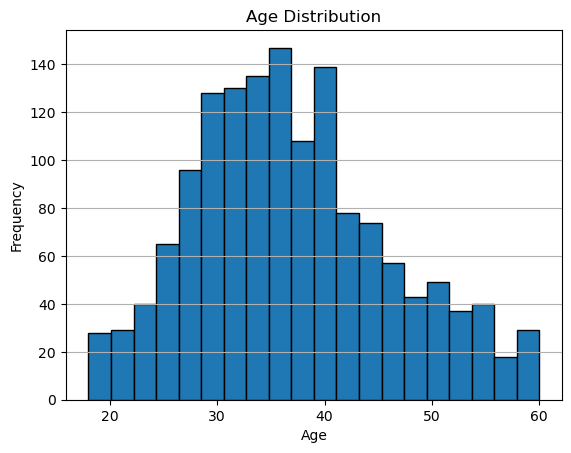

In [34]:
# Histogram of Age
df['Age'].plot(kind='hist', bins=20, edgecolor='black')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.grid(axis='y')
plt.show()


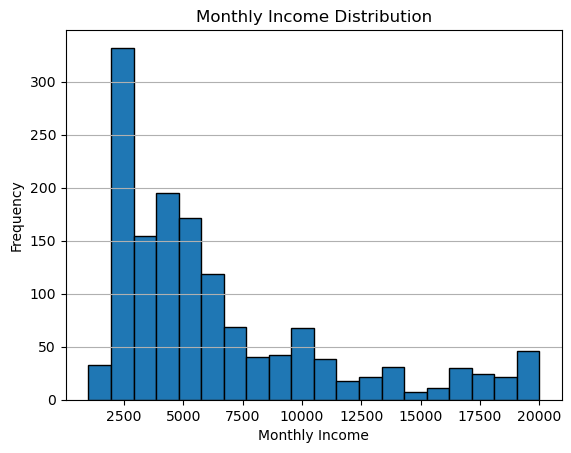

In [35]:
# Histogram of Monthly Income
df['MonthlyIncome'].plot(kind='hist', bins=20, edgecolor='black')
plt.title("Monthly Income Distribution")
plt.xlabel("Monthly Income")
plt.ylabel("Frequency")
plt.grid(axis='y')
plt.show()


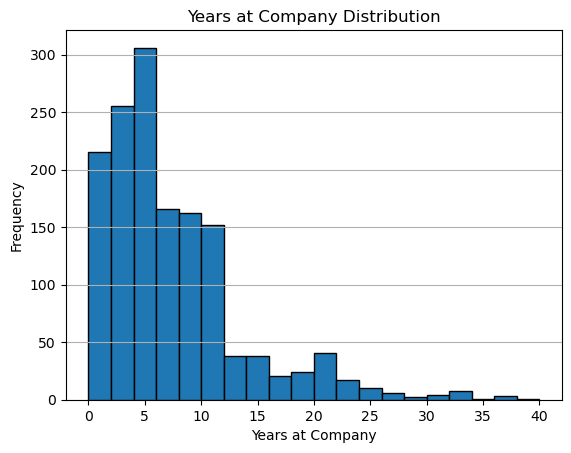

In [36]:
# Histogram of YearsAtCompany
df['YearsAtCompany'].plot(kind='hist', bins=20, edgecolor='black')
plt.title("Years at Company Distribution")
plt.xlabel("Years at Company")
plt.ylabel("Frequency")
plt.grid(axis='y')
plt.show()


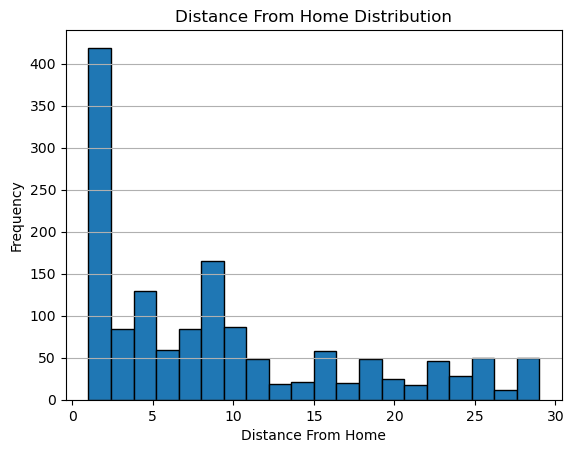

In [37]:
# Histogram of DistanceFromHome (hoem to office distance)
df['DistanceFromHome'].plot(kind='hist', bins=20, edgecolor='black')
plt.title("Distance From Home Distribution")
plt.xlabel("Distance From Home")
plt.ylabel("Frequency")
plt.grid(axis='y')
plt.show()


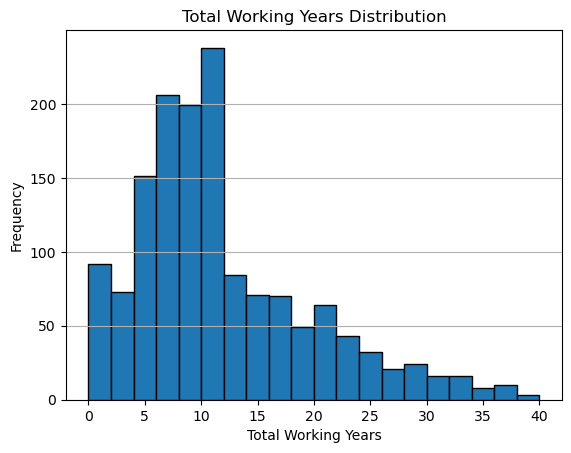

In [38]:
# Histogram of TotalWorkingYears
df['TotalWorkingYears'].plot(kind='hist', bins=20, edgecolor='black')
plt.title("Total Working Years Distribution")
plt.xlabel("Total Working Years")
plt.ylabel("Frequency")
plt.grid(axis='y')
plt.show()


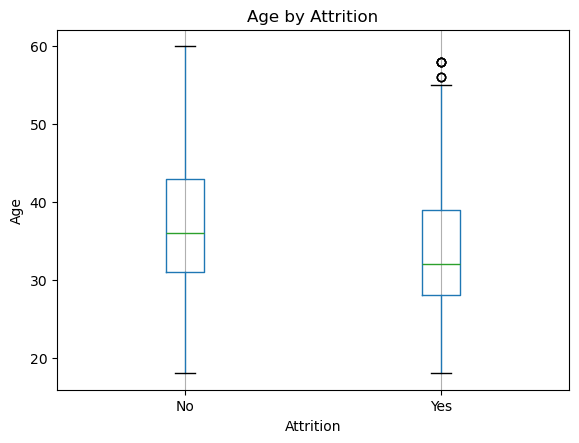

In [39]:
# Age vs Attrition
df.boxplot(column='Age', by='Attrition')
plt.title("Age by Attrition")
plt.suptitle('')
plt.xlabel("Attrition")
plt.ylabel("Age")
plt.grid(axis='y')
plt.show()


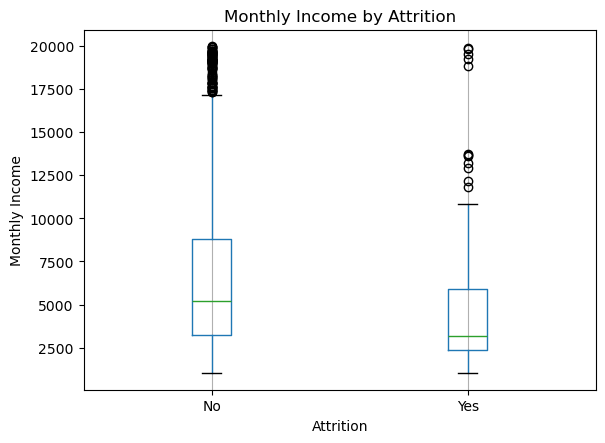

In [40]:
# MonthlyIncome vs Attrition
df.boxplot(column='MonthlyIncome', by='Attrition')
plt.title("Monthly Income by Attrition")
plt.suptitle('')
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.grid(axis='y')
plt.show()


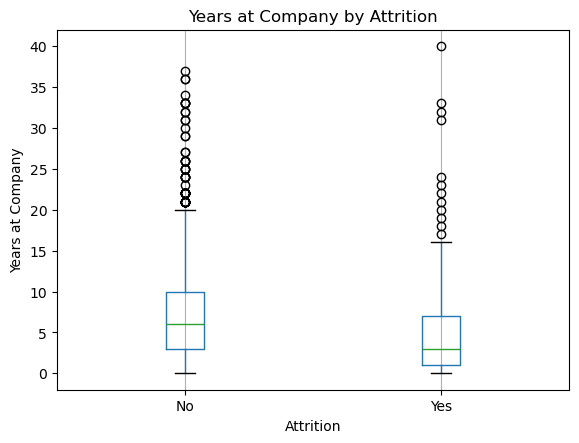

In [41]:
# YearsAtCompany vs Attrition
df.boxplot(column='YearsAtCompany', by='Attrition')
plt.title("Years at Company by Attrition")
plt.suptitle('')
plt.xlabel("Attrition")
plt.ylabel("Years at Company")
plt.grid(axis='y')
plt.show()


In [42]:
pd.crosstab(df['Department'], df['Attrition'], normalize='index') * 100


Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


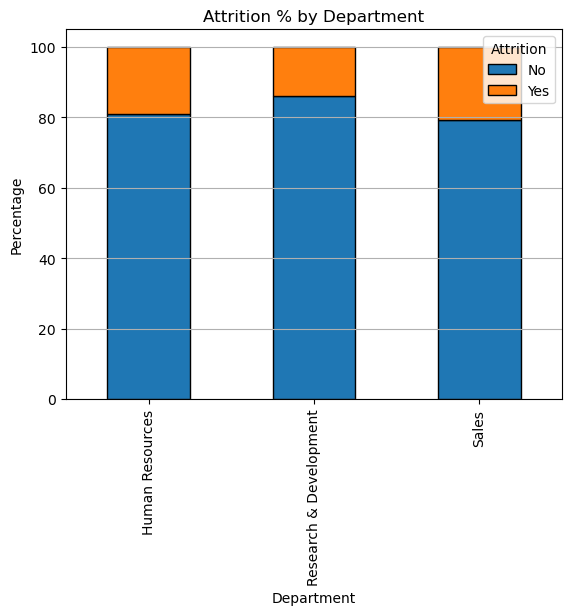

In [43]:
(pd.crosstab(df['Department'], df['Attrition'], normalize='index') * 100).plot(kind='bar', stacked=True, edgecolor='black')
plt.title("Attrition % by Department")
plt.xlabel("Department")
plt.ylabel("Percentage")
plt.grid(axis='y')
plt.show()


In [44]:
pd.crosstab(df['JobRole'], df['Attrition'], normalize='index') * 100


Attrition,No,Yes
JobRole,,
Healthcare Representative,93.129771,6.870229
Human Resources,76.923077,23.076923
Laboratory Technician,76.061776,23.938224
Manager,95.098039,4.901961
Manufacturing Director,93.103448,6.896552
Research Director,97.500000,2.500000
Research Scientist,83.904110,16.095890
Sales Executive,82.515337,17.484663
Sales Representative,60.240964,39.759036


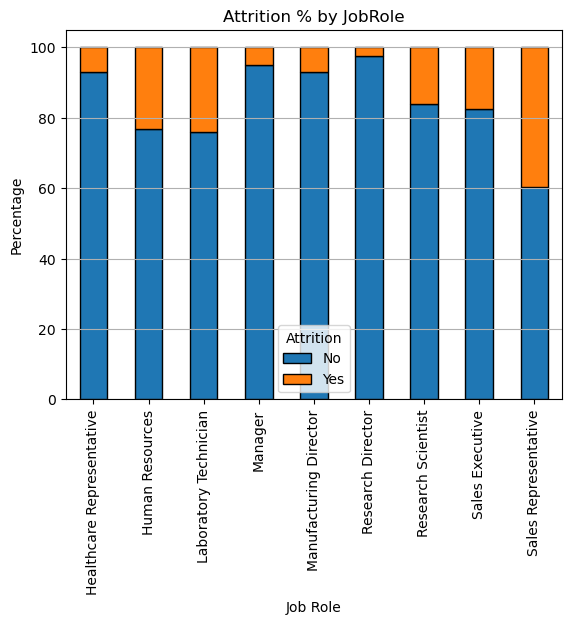

In [45]:
(pd.crosstab(df['JobRole'], df['Attrition'], normalize='index') * 100).plot(kind='bar', stacked=True, edgecolor='black')
plt.title("Attrition % by JobRole")
plt.xlabel("Job Role")
plt.ylabel("Percentage")
plt.grid(axis='y')
plt.show()


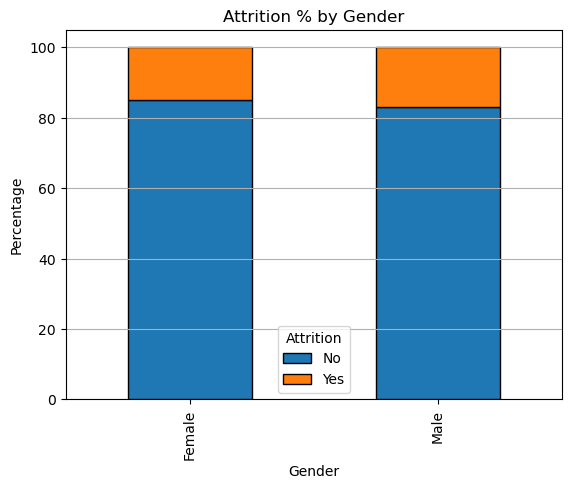

In [46]:
(pd.crosstab(df['Gender'], df['Attrition'], normalize='index') * 100).plot(kind='bar', stacked=True, edgecolor='black')
plt.title("Attrition % by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage")
plt.grid(axis='y')
plt.show()


In [48]:
pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100


Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


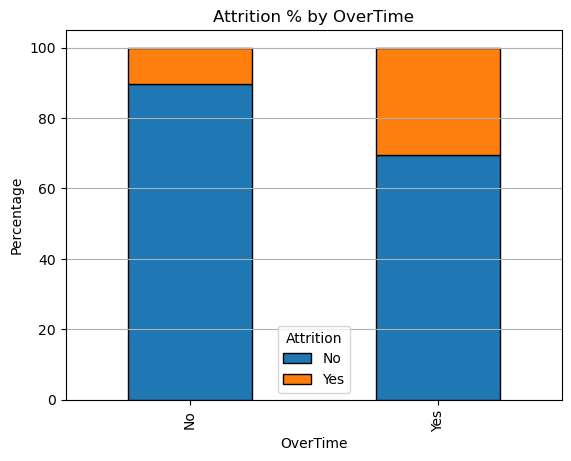

In [49]:
(pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100).plot(kind='bar', stacked=True, edgecolor='black')
plt.title("Attrition % by OverTime")
plt.xlabel("OverTime")
plt.ylabel("Percentage")
plt.grid(axis='y')
plt.show()



Sample correlations between features:

                       Age  DailyRate  DistanceFromHome  Education  \
Age               1.000000   0.010661         -0.001686   0.208034   
DailyRate         0.010661   1.000000         -0.004985  -0.016806   
DistanceFromHome -0.001686  -0.004985          1.000000   0.021042   
Education         0.208034  -0.016806          0.021042   1.000000   
EmployeeCount          NaN        NaN               NaN        NaN   

                  EmployeeCount  EmployeeNumber  EnvironmentSatisfaction  \
Age                         NaN       -0.010145                 0.010146   
DailyRate                   NaN       -0.050990                 0.018355   
DistanceFromHome            NaN        0.032916                -0.016075   
Education                   NaN        0.042070                -0.027128   
EmployeeCount               NaN             NaN                      NaN   

                  HourlyRate  JobInvolvement  JobLevel  ...  \
Age                

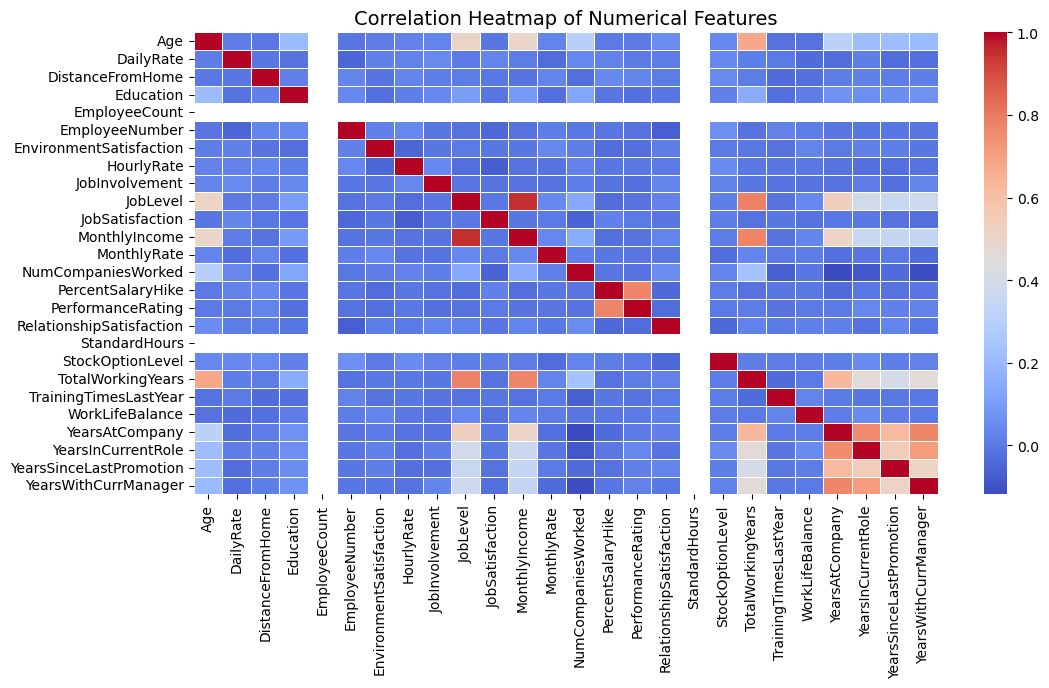

In [51]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Print first 5 correlations of dataset (just to preview)
print("\nSample correlations between features:\n")
print(corr_matrix.head())

# Plot correlation heatmap
plt.figure(figsize=(12,6))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14)
plt.show()


In [52]:
constant_cols = [col for col in df.columns if df[col].nunique() == 1]

print("\nConstant columns (same value in all rows):", constant_cols)

# Drop them
df = df.drop(columns=constant_cols)

print("\nShape after dropping constant columns:", df.shape)



Constant columns (same value in all rows): ['EmployeeCount', 'Over18', 'StandardHours']

Shape after dropping constant columns: (1470, 32)


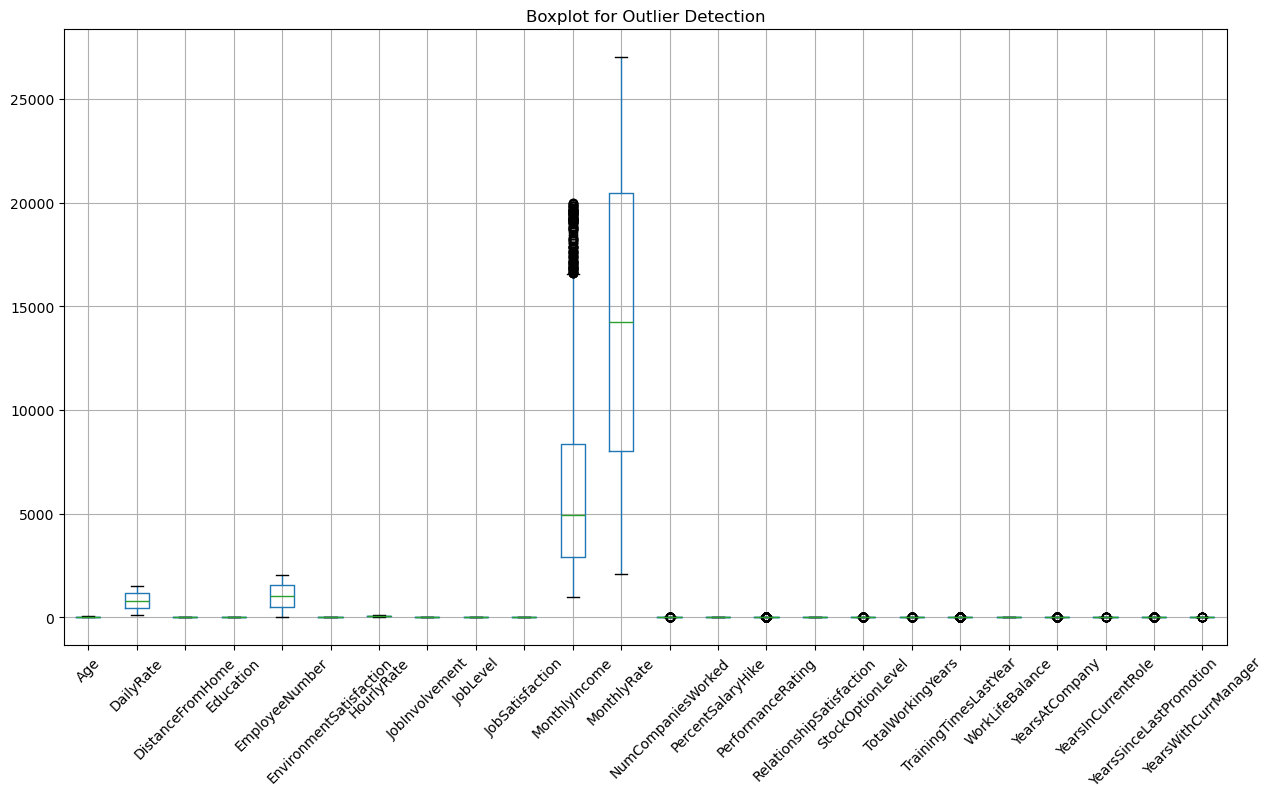

In [53]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Plot boxplots for all numeric columns
plt.figure(figsize=(15, 8))
df[numeric_cols].boxplot()
plt.title("Boxplot for Outlier Detection")
plt.xticks(rotation=45)
plt.show()


In [55]:
# Handle Outliers using IQR Method

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

# Keep only values within 1.5 * IQR range
df = df[~((df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

df.shape


(670, 32)

In [56]:
le = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 670 entries, 2 to 1469
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       670 non-null    int64
 1   Attrition                 670 non-null    int32
 2   BusinessTravel            670 non-null    int32
 3   DailyRate                 670 non-null    int64
 4   Department                670 non-null    int32
 5   DistanceFromHome          670 non-null    int64
 6   Education                 670 non-null    int64
 7   EducationField            670 non-null    int32
 8   EmployeeNumber            670 non-null    int64
 9   EnvironmentSatisfaction   670 non-null    int64
 10  Gender                    670 non-null    int32
 11  HourlyRate                670 non-null    int64
 12  JobInvolvement            670 non-null    int64
 13  JobLevel                  670 non-null    int64
 14  JobRole                   670 non-null    int3

In [60]:
# Features (X) and Target (y)
X = df.drop('MonthlyIncome', axis=1)   # Salary ki jagah MonthlyIncome hata diya
y = df['MonthlyIncome']                # Target column ab MonthlyIncome hai

# Check shape
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)


Shape of X: (670, 31)
Shape of y: (670,)


In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


Training data shape: (536, 31)
Testing data shape: (134, 31)


In [64]:
# Initialize the model
lr_model = LinearRegression()

# Train/Fit the model on training data
lr_model.fit(X_train, y_train)

print("✅ Model training complete!")


✅ Model training complete!


In [66]:
y_pred = lr_model.predict(X_test)

# Evaluation metrics calculate 
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("📊 Model Performance:")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R² Score: {r2}")


📊 Model Performance:
Mean Absolute Error (MAE): 896.8279587178588
Mean Squared Error (MSE): 1591364.6451927102
Root Mean Squared Error (RMSE): 1261.493022252882
R² Score: 0.7028468142637615


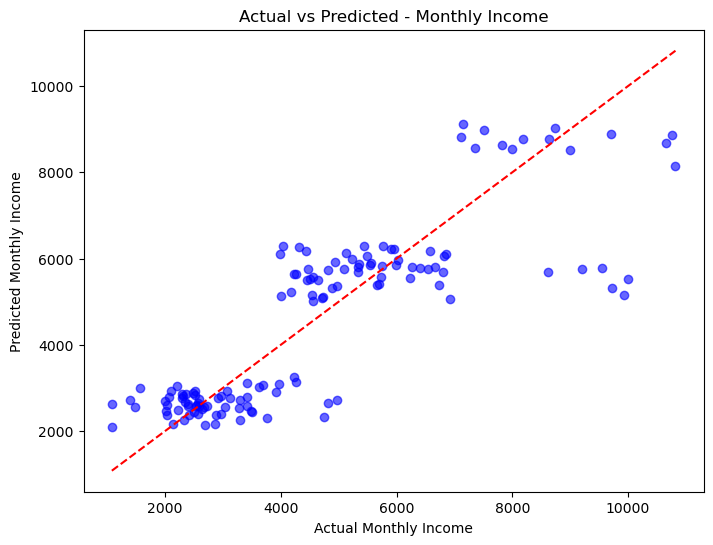

In [67]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6, color="blue")
plt.xlabel("Actual Monthly Income")
plt.ylabel("Predicted Monthly Income")
plt.title("Actual vs Predicted - Monthly Income")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect line
plt.show()


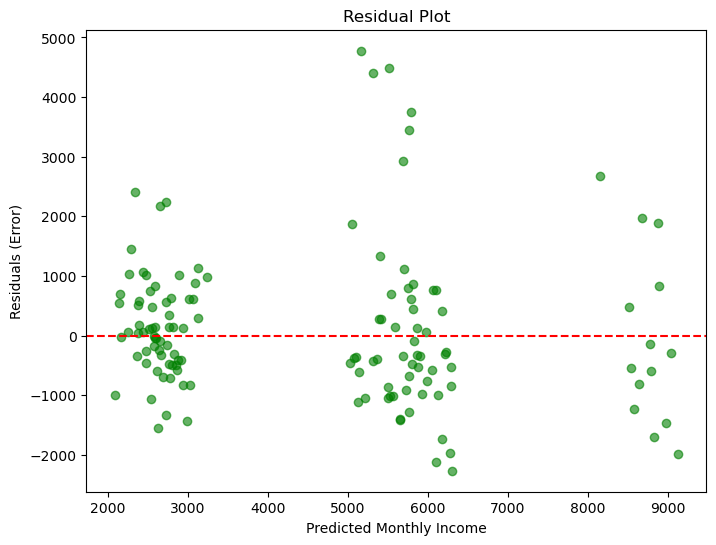

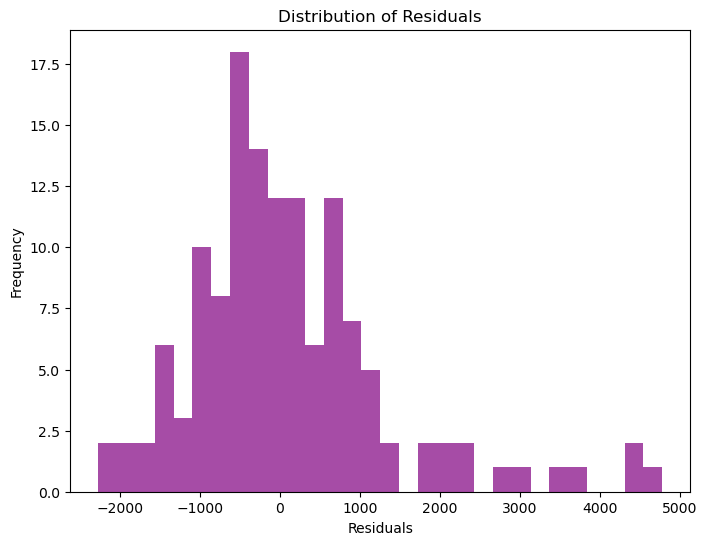

In [68]:
residuals = y_test - y_pred

# Residual plot
plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.6, color="green")
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Monthly Income")
plt.ylabel("Residuals (Error)")
plt.title("Residual Plot")
plt.show()

# Residuals distribution
plt.figure(figsize=(8,6))
plt.hist(residuals, bins=30, color="purple", alpha=0.7)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.show()


In [70]:
from sklearn.linear_model import LinearRegression

# Model initialize
model = LinearRegression()

# Train karna
model.fit(X_train, y_train)

# Predict karna
y_pred = model.predict(X_test)

# Accuracy check karna (R^2 Score)
from sklearn.metrics import r2_score, mean_squared_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))



R2 Score: 0.7028468142637615
MSE: 1591364.6451927102


In [71]:
# Feature Importance / Coefficients

# Get feature names after encoding
feature_names = X.columns  

# Get coefficients from the trained model
coefficients = model.coef_

# Combine feature names with their coefficients
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort by absolute value of coefficients
feature_importance['Importance'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Display top features
print(feature_importance.head(10))


                    Feature  Coefficient   Importance
13                 JobLevel  2821.767699  2821.767699
4                Department   254.607931   254.607931
2            BusinessTravel   245.859067   245.859067
19                 OverTime   175.787933   175.787933
1                 Attrition  -169.725668   169.725668
12           JobInvolvement  -129.715771   129.715771
10                   Gender   129.132176   129.132176
26          WorkLifeBalance   -78.967727    78.967727
29  YearsSinceLastPromotion    68.919307    68.919307
25    TrainingTimesLastYear   -59.669136    59.669136


In [72]:
# Feature Importance (Coefficients)
coefficients = pd.DataFrame(model.coef_, X.columns, columns=["Coefficient"])
coefficients.sort_values(by="Coefficient", ascending=False)


,Coefficient
JobLevel,2.821768e+03
Department,2.546079e+02
BusinessTravel,2.458591e+02
OverTime,1.757879e+02
Gender,1.291322e+02
YearsSinceLastPromotion,6.891931e+01
YearsInCurrentRole,4.013415e+01
Education,2.801577e+01
YearsWithCurrManager,1.897238e+01
EducationField,1.635759e+01


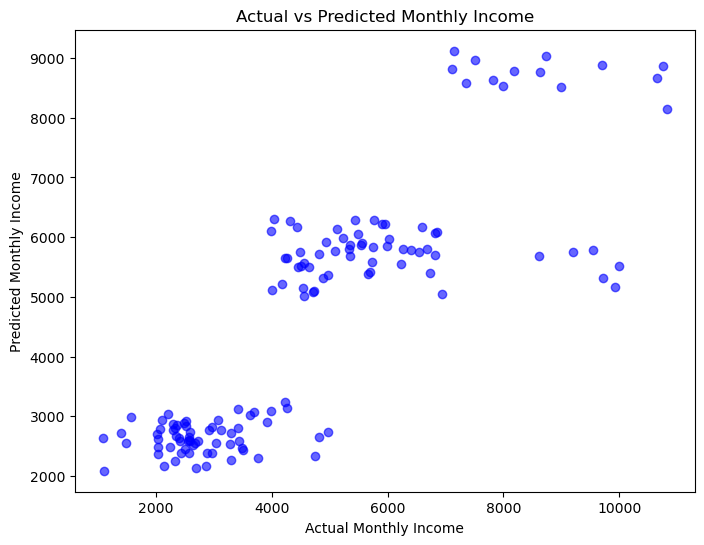

In [73]:
# Visualization - Actual vs Predicted
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6, color="blue")
plt.xlabel("Actual Monthly Income")
plt.ylabel("Predicted Monthly Income")
plt.title("Actual vs Predicted Monthly Income")
plt.show()


In [77]:
print("✅ Linear Regression Model Completed")
print("Model Evaluation Metrics:")
print(" - MAE (Mean Absolute Error):", mae)
print(" - MSE (Mean Squared Error):", mse)
print(" - RMSE (Root Mean Squared Error):", rmse)
print(" - R² Score:", r2)

print("\n👉 Next Improvements:")
print("1. Feature Engineering – Use more columns like Age, Department, Experience, etc.")
print("2. Scaling – Apply StandardScaler/MinMaxScaler to improve accuracy.")
print("3. Other Algorithms – Try models like RandomForest, XGBoost for better performance.")
print("4. Cross Validation – Use cross-validation in addition to train-test split to check stability.")


✅ Linear Regression Model Completed
Model Evaluation Metrics:
 - MAE (Mean Absolute Error): 896.8279587178588
 - MSE (Mean Squared Error): 1591364.6451927102
 - RMSE (Root Mean Squared Error): 1261.493022252882
 - R² Score: 0.7028468142637615

👉 Next Improvements:
1. Feature Engineering – Use more columns like Age, Department, Experience, etc.
2. Scaling – Apply StandardScaler/MinMaxScaler to improve accuracy.
3. Other Algorithms – Try models like RandomForest, XGBoost for better performance.
4. Cross Validation – Use cross-validation in addition to train-test split to check stability.


In [78]:
# Step 10: Save the trained model
import joblib

# Save model
joblib.dump(model, "linear_regression_model.pkl")
print("✅ Model saved as 'linear_regression_model.pkl'")

# Load model (whenever needed)
loaded_model = joblib.load("linear_regression_model.pkl")
print("✅ Model loaded successfully")


✅ Model saved as 'linear_regression_model.pkl'
✅ Model loaded successfully
